In [1]:
# ============================================================
# ETAPA 1 - IMPORTAÇÃO DOS MÓDULOS PARA MAGNETOMETRIA
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from gravmag_codes import synthetic
from gravmag_codes import prism
from gravmag_codes import sphere
from gravmag_codes import cylinder
from gravmag_codes import polygonalprism
from gravmag_codes import filtering
from gravmag_codes import derivative
from gravmag_codes import plotting

print("Módulos importados com sucesso!")

Módulos importados com sucesso!


In [2]:
# ============================================================
# ETAPA 2 - GRID DE OBSERVAÇÃO MAGNÉTICA
# ============================================================

# Área do levantamento em metros
area_mag = [0.0, 10000.0, 0.0, 10000.0]

# Número de pontos
shape_mag = (101, 101)

# Altura/nível de observação
# z positivo para baixo
observation_level_mag = 0.0

x_mag, y_mag, z_mag = synthetic.my_make_observation_grid(
    area=area_mag,
    shape=shape_mag,
    level=observation_level_mag,
    flatten=False
)

print("Grid magnético criado com sucesso!")
print("Shape:", x_mag.shape)
print("X mínimo/máximo:", x_mag.min(), x_mag.max())
print("Y mínimo/máximo:", y_mag.min(), y_mag.max())

Grid magnético criado com sucesso!
Shape: (101, 101)
X mínimo/máximo: 0.0 10000.0
Y mínimo/máximo: 0.0 10000.0


In [3]:
# ============================================================
# ETAPA 3 - MODELO MAGNÉTICO COM PRISMAS
# ============================================================

# Centros dos prismas
xprism_mag = np.array([3000.0, 6500.0])
yprism_mag = np.array([5000.0, 5500.0])

# Topo e base dos prismas
top_mag = np.array([500.0, 800.0])
bottom_mag = np.array([2500.0, 3000.0])

# Dimensões horizontais
dx_mag = 1200.0
dy_mag = 1200.0

# Magnetização em A/m
magnetization = np.array([2.0, 3.0])

prisms_mag = synthetic.my_synthetic_prism_model(
    centers_x=xprism_mag,
    centers_y=yprism_mag,
    top=top_mag,
    bottom=bottom_mag,
    dx=dx_mag,
    dy=dy_mag,
    density=magnetization
)

print("Modelo magnético criado com sucesso!")
print("Número de prismas:", len(prisms_mag))

for i, p in enumerate(prisms_mag):
    print(f"Prisma {i+1}: {p}")

Modelo magnético criado com sucesso!
Número de prismas: 2
Prisma 1: [2400.0, 3600.0, 4400.0, 5600.0, 500.0, 2500.0, 2.0]
Prisma 2: [5900.0, 7100.0, 4900.0, 6100.0, 800.0, 3000.0, 3.0]


In [4]:
# ============================================================
# ETAPA 4 - CAMPO MAGNÉTICO REGIONAL
# ============================================================

# Inclinação e declinação do campo principal
inc = -20.0   # graus
dec = -10.0   # graus

# Inclinação e declinação da magnetização das fontes
# Neste primeiro teste, vamos assumir magnetização induzida,
# isto é, mesma direção do campo regional.
incs = inc
decs = dec

print("Campo magnético regional definido:")
print("Inclinação:", inc, "graus")
print("Declinação:", dec, "graus")
print("Inclinação da magnetização:", incs, "graus")
print("Declinação da magnetização:", decs, "graus")

Campo magnético regional definido:
Inclinação: -20.0 graus
Declinação: -10.0 graus
Inclinação da magnetização: -20.0 graus
Declinação da magnetização: -10.0 graus


In [5]:
# ============================================================
# ETAPA 5 - ANOMALIA DE CAMPO TOTAL DOS PRISMAS
# ============================================================

tfa_prisms = synthetic.my_forward_prisms_tfa(
    x=x_mag,
    y=y_mag,
    z=z_mag,
    prisms=prisms_mag,
    inc=inc,
    dec=dec,
    incs=incs,
    decs=decs
)

print("Anomalia de campo total calculada com sucesso!")
print("TFA mínimo:", np.min(tfa_prisms), "nT")
print("TFA máximo:", np.max(tfa_prisms), "nT")
print("TFA médio:", np.mean(tfa_prisms), "nT")

Anomalia de campo total calculada com sucesso!
TFA mínimo: -212.70066647201492 nT
TFA máximo: 144.97882997863394 nT
TFA médio: -5.457988553298281 nT


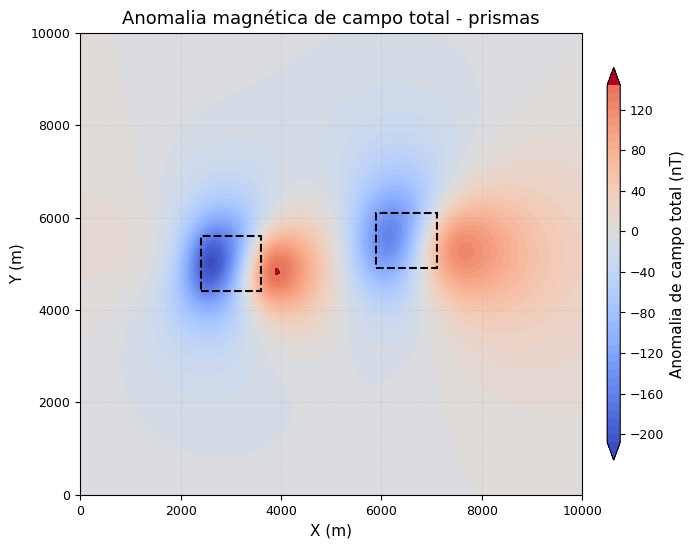

In [6]:
# ============================================================
# ETAPA 6 - PLOT DA ANOMALIA MAGNÉTICA DOS PRISMAS
# ============================================================

fig_tfa, ax_tfa, cf_tfa = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Anomalia de campo total (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Anomalia magnética de campo total - prismas"
)

# Desenha a projeção horizontal dos prismas
for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tfa,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [7]:
# ============================================================
# ETAPA 5A - COMPONENTES MAGNÉTICAS Bx, By e Bz DOS PRISMAS
# ============================================================

# Componente Bx
Bx_prisms = prism.my_prisms_bx(
    x=x_mag,
    y=y_mag,
    z=z_mag,
    prisms=prisms_mag,
    inc=inc,
    dec=dec,
    incs=incs,
    decs=decs
)

# Componente By
By_prisms = prism.my_prisms_by(
    x=x_mag,
    y=y_mag,
    z=z_mag,
    prisms=prisms_mag,
    inc=inc,
    dec=dec,
    incs=incs,
    decs=decs
)

# Componente Bz
Bz_prisms = prism.my_prisms_bz(
    x=x_mag,
    y=y_mag,
    z=z_mag,
    prisms=prisms_mag,
    inc=inc,
    dec=dec,
    incs=incs,
    decs=decs
)

print("Componentes magnéticas calculadas com sucesso!")
print("Bx mínimo/máximo:", np.min(Bx_prisms), np.max(Bx_prisms), "nT")
print("By mínimo/máximo:", np.min(By_prisms), np.max(By_prisms), "nT")
print("Bz mínimo/máximo:", np.min(Bz_prisms), np.max(Bz_prisms), "nT")

Componentes magnéticas calculadas com sucesso!
Bx mínimo/máximo: -220.91929899750724 101.24415084906511 nT
By mínimo/máximo: -100.19151735495814 133.11114721875367 nT
Bz mínimo/máximo: -277.22773468988555 153.92303607179437 nT


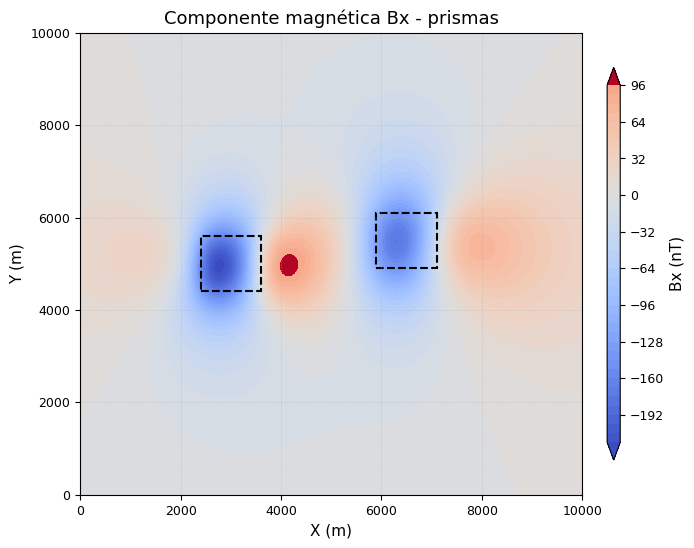

In [8]:
# ============================================================
# ETAPA 5B - PLOT DA COMPONENTE Bx
# ============================================================

fig_bx, ax_bx, cf_bx = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=Bx_prisms,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Bx (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Componente magnética Bx - prismas"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_bx,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

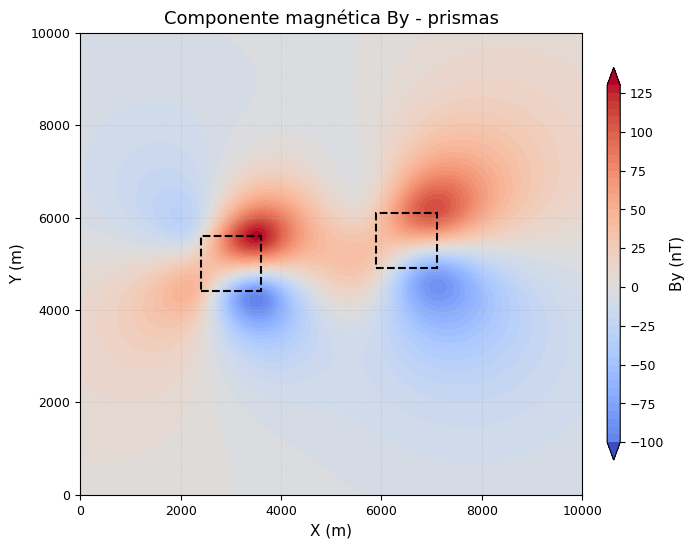

In [9]:
# ============================================================
# ETAPA 5C - PLOT DA COMPONENTE By
# ============================================================

fig_by, ax_by, cf_by = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=By_prisms,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="By (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Componente magnética By - prismas"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_by,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

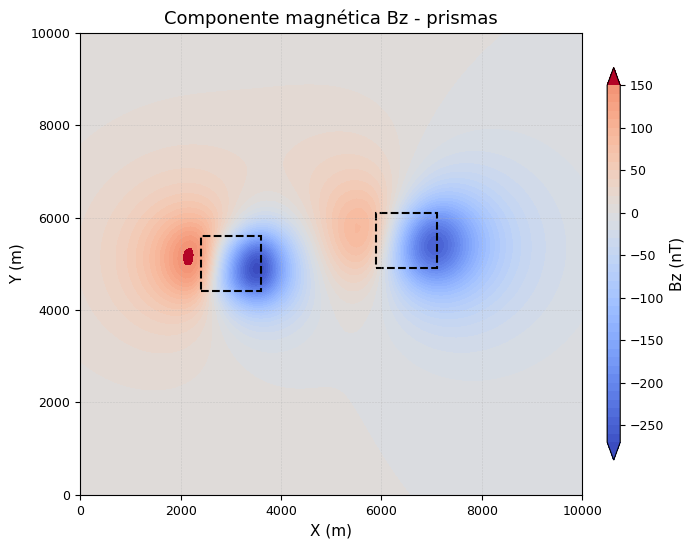

In [10]:
# ============================================================
# ETAPA 5D - PLOT DA COMPONENTE Bz
# ============================================================

fig_bz_mag, ax_bz_mag, cf_bz_mag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=Bz_prisms,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Bz (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Componente magnética Bz - prismas"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_bz_mag,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

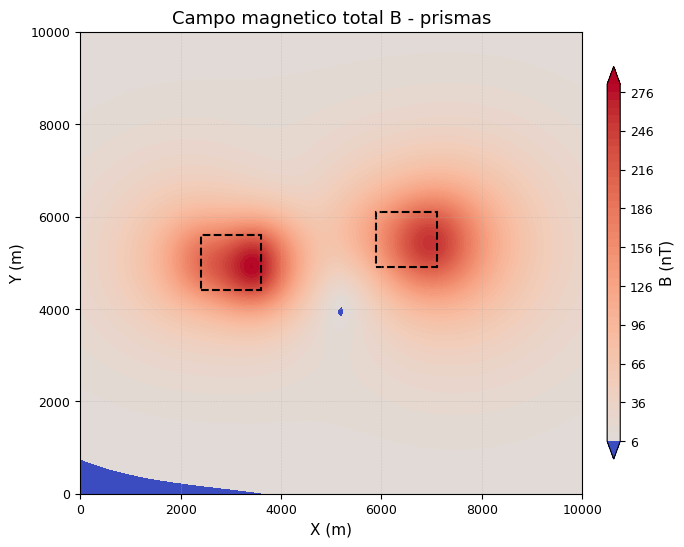

In [11]:
# ============================================================
# ETAPA 5D - PLOT DO CAMPO MAGNETICO B
# ============================================================
B_total = np.sqrt((Bx_prisms)**2 + (By_prisms)**2 + (Bz_prisms)**2)

fig_bz_mag, ax_bz_mag, cf_bz_mag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=B_total,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="B (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Campo magnetico total B - prismas"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_bz_mag,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [12]:
# ============================================================
# ETAPA 7 - DERIVADAS HORIZONTAIS DA ANOMALIA MAGNÉTICA
# ============================================================

tfa_dx = derivative.my_xderiv(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

tfa_dy = derivative.my_yderiv(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivadas horizontais calculadas com sucesso!")
print("dT/dx mínimo/máximo:", np.min(tfa_dx), np.max(tfa_dx))
print("dT/dy mínimo/máximo:", np.min(tfa_dy), np.max(tfa_dy))

Derivadas horizontais calculadas com sucesso!
dT/dx mínimo/máximo: -0.29461588613342327 0.43084989002329926
dT/dy mínimo/máximo: -0.17644761786251192 0.15613489556128154


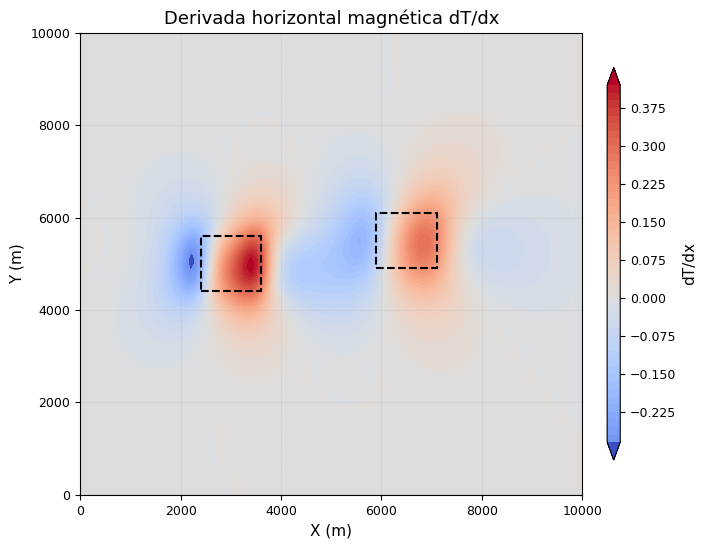

In [13]:
# ============================================================
# PLOT - DERIVADA HORIZONTAL dT/dx
# ============================================================

fig_tfa_dx, ax_tfa_dx, cf_tfa_dx = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_dx,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dT/dx",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada horizontal magnética dT/dx"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tfa_dx,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

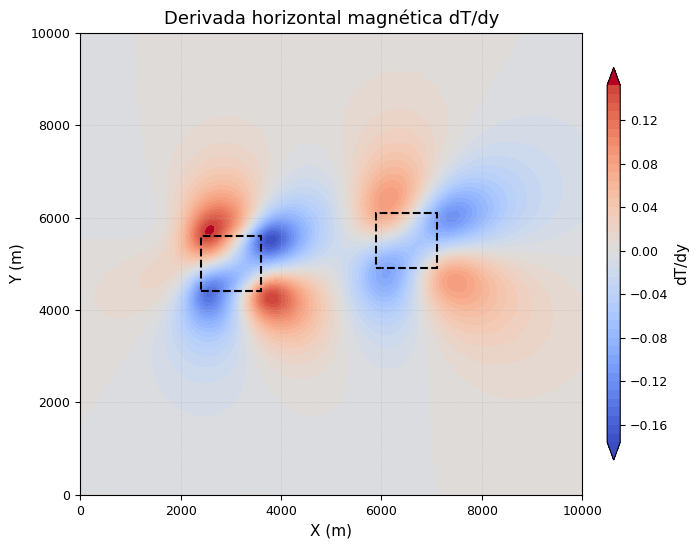

In [14]:
# ============================================================
# PLOT - DERIVADA HORIZONTAL dT/dy
# ============================================================

fig_tfa_dy, ax_tfa_dy, cf_tfa_dy = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_dy,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dT/dy",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada horizontal magnética dT/dy"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tfa_dy,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [15]:
# ============================================================
# ETAPA 8 - DERIVADA VERTICAL DA ANOMALIA MAGNÉTICA
# ============================================================

tfa_dz = derivative.my_zderiv(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivada vertical magnética calculada com sucesso!")
print("dT/dz mínimo/máximo:", np.min(tfa_dz), np.max(tfa_dz))

Derivada vertical magnética calculada com sucesso!
dT/dz mínimo/máximo: -0.48066646514484807 0.4348429067793723


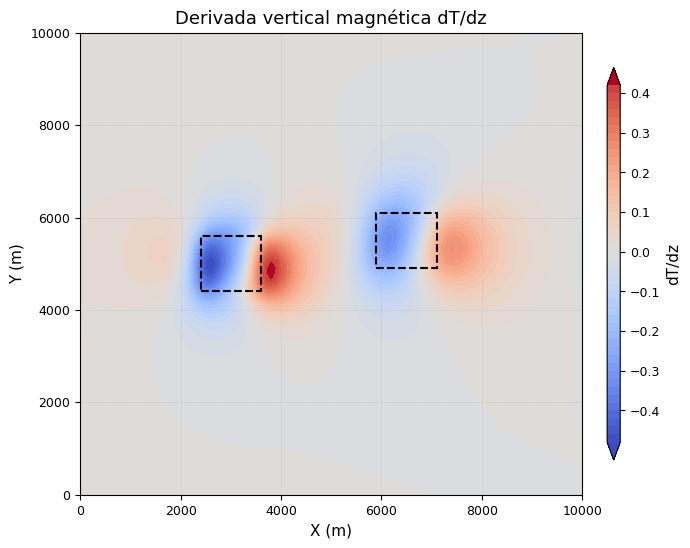

In [16]:
# ============================================================
# PLOT - DERIVADA VERTICAL dT/dz
# ============================================================

fig_tfa_dz, ax_tfa_dz, cf_tfa_dz = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_dz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dT/dz",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada vertical magnética dT/dz"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tfa_dz,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [17]:
# ============================================================
# ETAPA 9 - GRADIENTE HORIZONTAL TOTAL MAGNÉTICO
# ============================================================

hgm_tfa = derivative.my_hgrad(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("HGM magnético calculado com sucesso!")
print("HGM mínimo/máximo:", np.min(hgm_tfa), np.max(hgm_tfa))

HGM magnético calculado com sucesso!
HGM mínimo/máximo: 5.745245290400934e-06 0.4372237165504854


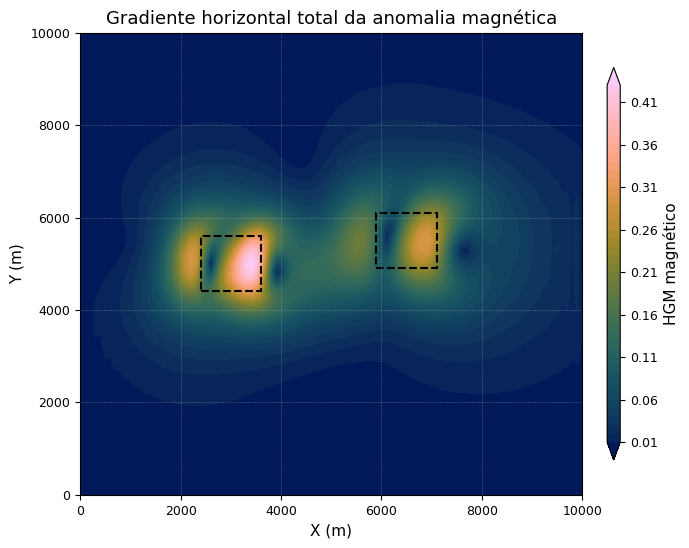

In [18]:
# ============================================================
# PLOT - HGM MAGNÉTICO
# ============================================================

fig_hgm_tfa, ax_hgm_tfa, cf_hgm_tfa = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=hgm_tfa,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="HGM magnético",
    colormap="batlow",
    levels=50,
    title="Gradiente horizontal total da anomalia magnética"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_hgm_tfa,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [19]:
# ============================================================
# ETAPA 10 - SINAL ANALÍTICO MAGNÉTICO
# ============================================================

asa_tfa = derivative.my_totalgrad(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Sinal analítico magnético calculado com sucesso!")
print("ASA mínimo/máximo:", np.min(asa_tfa), np.max(asa_tfa))

Sinal analítico magnético calculado com sucesso!
ASA mínimo/máximo: 0.001452760050812676 0.4807028210350841


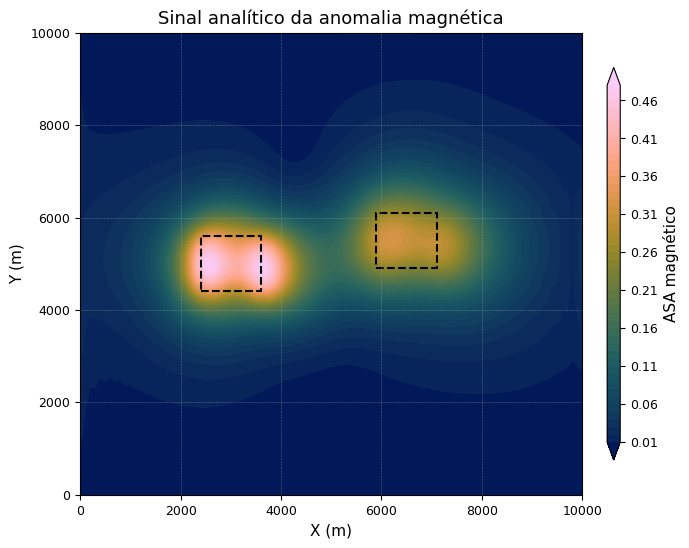

In [20]:
# ============================================================
# PLOT - SINAL ANALÍTICO MAGNÉTICO
# ============================================================

fig_asa_tfa, ax_asa_tfa, cf_asa_tfa = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=asa_tfa,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="ASA magnético",
    colormap="batlow",
    levels=50,
    title="Sinal analítico da anomalia magnética"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_asa_tfa,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [21]:
# ============================================================
# ETAPA 11 - TILT ANGLE MAGNÉTICO
# ============================================================

tilt_tfa = filtering.my_tilt(
    x=x_mag,
    y=y_mag,
    data=tfa_prisms,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    degrees=True,
    flatten=False
)

print("Tilt magnético calculado com sucesso!")
print("Tilt mínimo/máximo:", np.min(tilt_tfa), np.max(tilt_tfa), "graus")

Tilt magnético calculado com sucesso!
Tilt mínimo/máximo: -89.7418130636633 89.95990458383883 graus


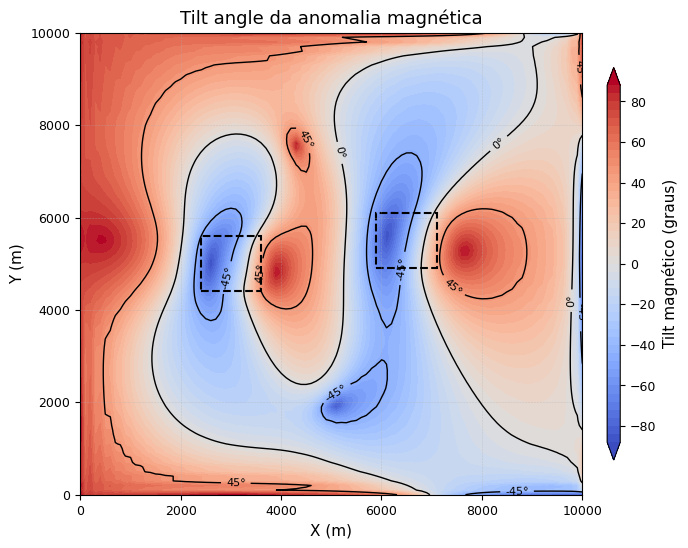

In [22]:
# ============================================================
# PLOT - TILT ANGLE MAGNÉTICO
# ============================================================

fig_tilt_tfa, ax_tilt_tfa, cf_tilt_tfa = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tilt_tfa,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Tilt magnético (graus)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Tilt angle da anomalia magnética"
)

plotting.my_contour(
    x=x_mag,
    y=y_mag,
    data=tilt_tfa,
    ax=ax_tilt_tfa,
    levels=[-45, 0, 45],
    colors="black",
    linewidths=1.0,
    linestyles="-",
    clabel=True,
    clabel_fmt="%.0f°"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tilt_tfa,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [23]:
# ============================================================
# ETAPA 12 - CAMPO MAGNÉTICO REGIONAL SINTÉTICO
# ============================================================

# Normalização das coordenadas para evitar valores muito grandes no polinômio
x_norm = (x_mag - np.mean(x_mag)) / (np.max(x_mag) - np.min(x_mag))
y_norm = (y_mag - np.mean(y_mag)) / (np.max(y_mag) - np.min(y_mag))

# Campo regional sintético em nT
regional_mag = (
    150.0
    + 80.0*x_norm
    - 60.0*y_norm
    + 40.0*x_norm*y_norm
    + 30.0*x_norm**2
    - 20.0*y_norm**2
)

print("Campo magnético regional sintético criado com sucesso!")
print("Regional mínimo:", np.min(regional_mag), "nT")
print("Regional máximo:", np.max(regional_mag), "nT")
print("Regional médio:", np.mean(regional_mag), "nT")

Campo magnético regional sintético criado com sucesso!
Regional mínimo: 72.5 nT
Regional máximo: 212.5 nT
Regional médio: 150.85000000000002 nT


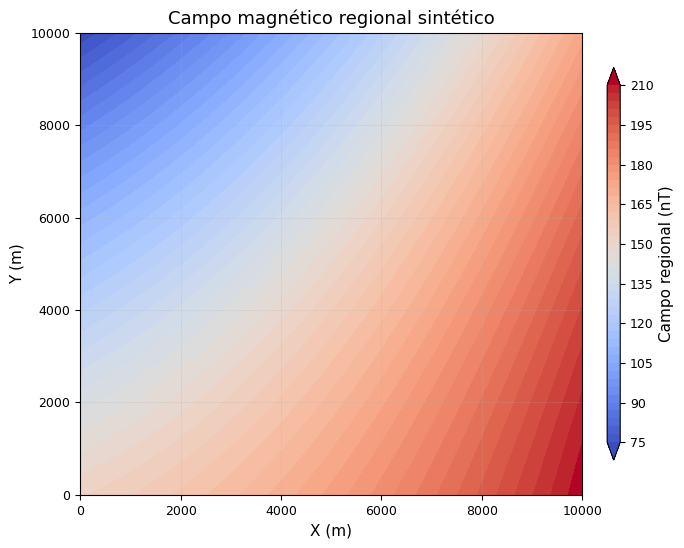

In [24]:
# ============================================================
# ETAPA 13 - PLOT DO CAMPO MAGNÉTICO REGIONAL
# ============================================================

fig_reg_mag, ax_reg_mag, cf_reg_mag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=regional_mag,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Campo regional (nT)",
    colormap="coolwarm",
    levels=50,
    title="Campo magnético regional sintético"
)

plt.show()

In [25]:
# ============================================================
# ETAPA 14 - CAMPO MAGNÉTICO OBSERVADO
# ============================================================

tfa_observed = regional_mag + tfa_prisms

print("Campo magnético observado criado com sucesso!")
print("Observado mínimo:", np.min(tfa_observed), "nT")
print("Observado máximo:", np.max(tfa_observed), "nT")
print("Observado médio:", np.mean(tfa_observed), "nT")

Campo magnético observado criado com sucesso!
Observado mínimo: -80.1726664720149 nT
Observado máximo: 295.77977556516225 nT
Observado médio: 145.39201144670176 nT


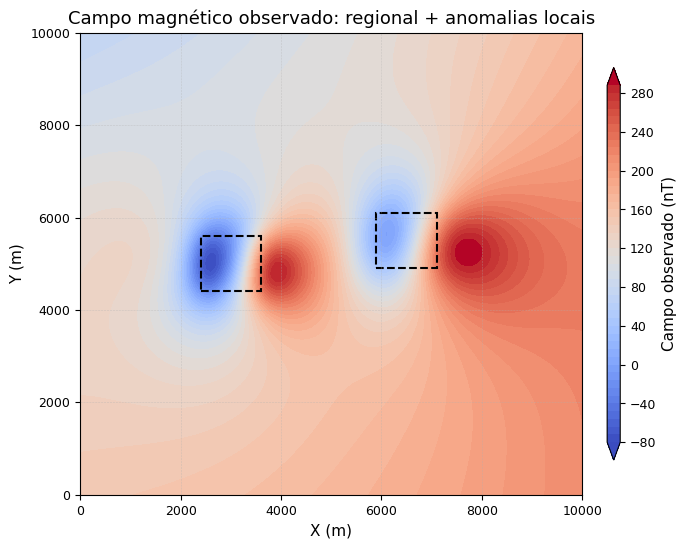

In [26]:
# ============================================================
# ETAPA 15 - PLOT DO CAMPO MAGNÉTICO OBSERVADO
# ============================================================

fig_obs_mag, ax_obs_mag, cf_obs_mag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_observed,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Campo observado (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=False,
    title="Campo magnético observado: regional + anomalias locais"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_obs_mag,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [27]:
# ============================================================
# ETAPA 16 - REMOÇÃO DO CAMPO REGIONAL CONHECIDO
# ============================================================

tfa_residual_known = tfa_observed - regional_mag

print("Residual magnético calculado com sucesso!")
print("Residual mínimo:", np.min(tfa_residual_known), "nT")
print("Residual máximo:", np.max(tfa_residual_known), "nT")
print("Residual médio:", np.mean(tfa_residual_known), "nT")

Residual magnético calculado com sucesso!
Residual mínimo: -212.70066647201492 nT
Residual máximo: 144.97882997863394 nT
Residual médio: -5.457988553298281 nT


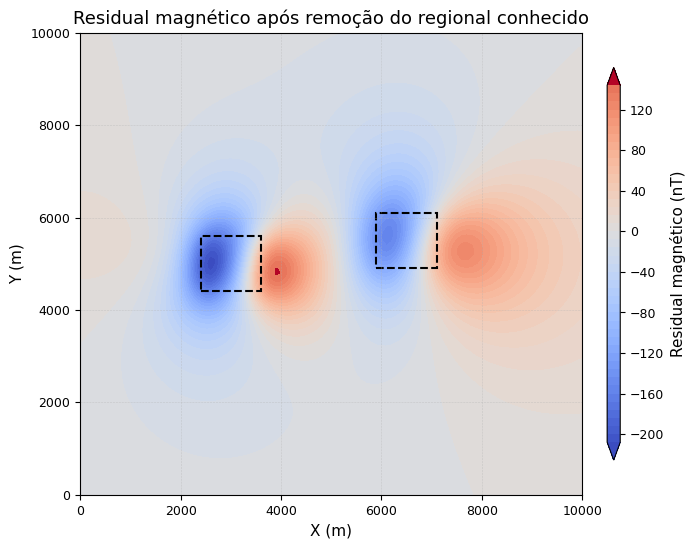

In [28]:
# ============================================================
# ETAPA 17 - PLOT DO RESIDUAL MAGNÉTICO
# ============================================================

fig_res_mag, ax_res_mag, cf_res_mag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_known,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual magnético (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Residual magnético após remoção do regional conhecido"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_mag,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [29]:
# ============================================================
# ETAPA 18 - COMPARAÇÃO ENTRE RESIDUAL E ANOMALIA ORIGINAL
# ============================================================

erro_residual = tfa_residual_known - tfa_prisms

rmse_residual = np.sqrt(np.mean(erro_residual**2))
erro_max_residual = np.max(np.abs(erro_residual))

print("Comparação residual conhecido x anomalia original")
print("RMSE:", rmse_residual, "nT")
print("Erro máximo absoluto:", erro_max_residual, "nT")

Comparação residual conhecido x anomalia original
RMSE: 7.446562420849677e-15 nT
Erro máximo absoluto: 2.842170943040401e-14 nT


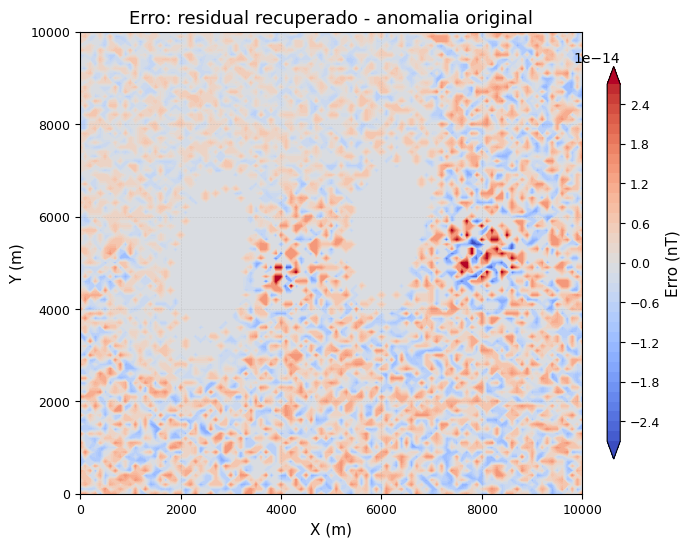

In [30]:
# ============================================================
# PLOT - ERRO ENTRE RESIDUAL E ANOMALIA ORIGINAL
# ============================================================

fig_err_res, ax_err_res, cf_err_res = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=erro_residual,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Erro (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Erro: residual recuperado - anomalia original"
)

plt.show()

In [31]:
# ============================================================
# ETAPA 19 - FUNÇÃO PARA AJUSTE POLINOMIAL 2D
# ============================================================

def design_matrix_polynomial_2d(x, y, degree=2):
    """
    Cria a matriz de desenho para ajuste polinomial 2D.
    
    Para degree=1:
        a0 + a1*x + a2*y
    
    Para degree=2:
        a0 + a1*x + a2*y + a3*x*y + a4*x² + a5*y²
    
    Para degree=3:
        inclui termos cúbicos.
    """
    
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    
    columns = []
    
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            columns.append((x**i)*(y**j))
    
    G = np.vstack(columns).T
    
    return G


def fit_polynomial_regional_2d(x, y, data, degree=2):
    """
    Ajusta uma superfície polinomial 2D aos dados.
    
    Inputs:
        x, y - coordenadas 2D
        data - campo observado 2D
        degree - grau do polinômio
        
    Output:
        regional_estimated - campo regional estimado 2D
        coefficients - coeficientes do polinômio
    """
    
    shape_original = data.shape
    
    # Normaliza coordenadas para evitar instabilidade numérica
    xn = (x - np.mean(x)) / (np.max(x) - np.min(x))
    yn = (y - np.mean(y)) / (np.max(y) - np.min(y))
    
    G = design_matrix_polynomial_2d(
        x=xn,
        y=yn,
        degree=degree
    )
    
    d = data.ravel()
    
    coefficients, residuals, rank, singular_values = np.linalg.lstsq(
        G,
        d,
        rcond=None
    )
    
    regional_estimated = (G @ coefficients).reshape(shape_original)
    
    return regional_estimated, coefficients

In [32]:
# ============================================================
# ETAPA 20 - ESTIMAR REGIONAL POR POLINÔMIO DE GRAU 2
# ============================================================

degree_regional = 2

regional_poly2, coef_poly2 = fit_polynomial_regional_2d(
    x=x_mag,
    y=y_mag,
    data=tfa_observed,
    degree=degree_regional
)

print("Campo regional estimado por polinômio criado com sucesso!")
print("Grau do polinômio:", degree_regional)
print("Coeficientes:", coef_poly2)
print("Regional estimado mínimo:", np.min(regional_poly2), "nT")
print("Regional estimado máximo:", np.max(regional_poly2), "nT")

Campo regional estimado por polinômio criado com sucesso!
Grau do polinômio: 2
Coeficientes: [133.78705394 -67.75156706 -20.66737667 114.87614532  13.76553614
 157.19628853]
Regional estimado mínimo: 71.16800550265557 nT
Regional estimado máximo: 255.79175406170287 nT


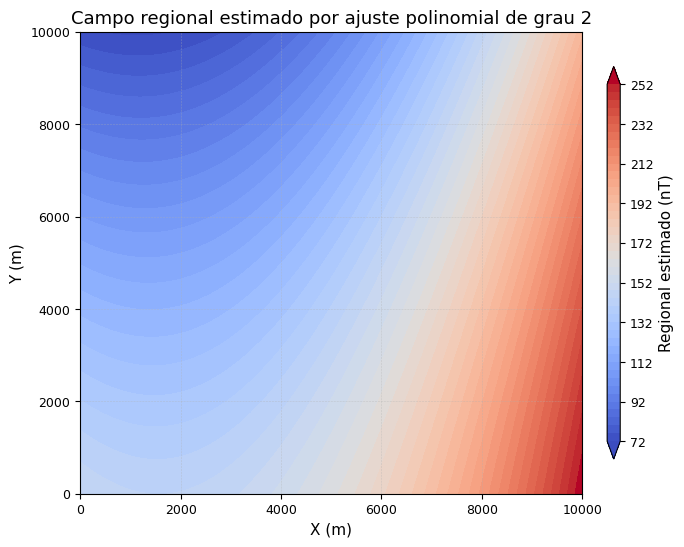

In [33]:
# ============================================================
# ETAPA 21 - PLOT DO REGIONAL ESTIMADO POR POLINÔMIO
# ============================================================

fig_reg_poly2, ax_reg_poly2, cf_reg_poly2 = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=regional_poly2,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Regional estimado (nT)",
    colormap="coolwarm",
    levels=50,
    title="Campo regional estimado por ajuste polinomial de grau 2"
)

plt.show()

In [34]:
# ============================================================
# ETAPA 22 - RESIDUAL MAGNÉTICO COM REGIONAL ESTIMADO
# ============================================================

tfa_residual_poly2 = tfa_observed - regional_poly2

print("Residual magnético por ajuste polinomial calculado com sucesso!")
print("Residual mínimo:", np.min(tfa_residual_poly2), "nT")
print("Residual máximo:", np.max(tfa_residual_poly2), "nT")
print("Residual médio:", np.mean(tfa_residual_poly2), "nT")

Residual magnético por ajuste polinomial calculado com sucesso!
Residual mínimo: -195.44395175281102 nT
Residual máximo: 163.39202836412775 nT
Residual médio: 3.8917207854512615e-14 nT


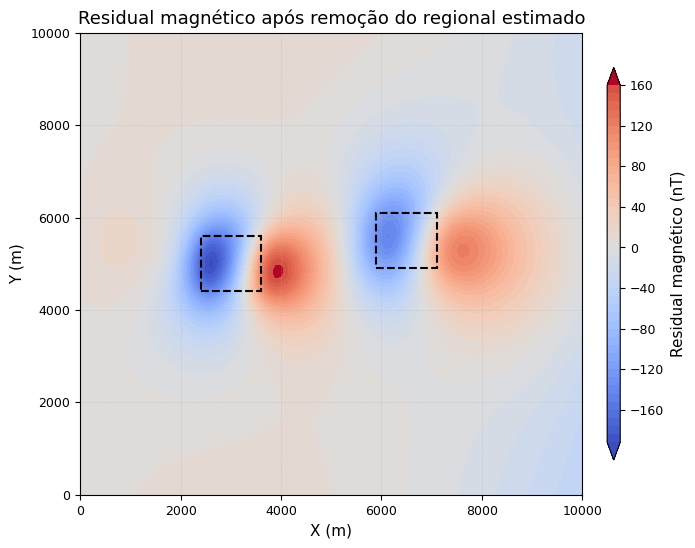

In [35]:
# ============================================================
# ETAPA 23 - PLOT DO RESIDUAL POR AJUSTE POLINOMIAL
# ============================================================

fig_res_poly2, ax_res_poly2, cf_res_poly2 = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_poly2,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual magnético (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Residual magnético após remoção do regional estimado"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_poly2,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [36]:
# ============================================================
# ETAPA 24 - ERRO DO RESIDUAL ESTIMADO
# ============================================================

erro_poly2 = tfa_residual_poly2 - tfa_prisms

rmse_poly2 = np.sqrt(np.mean(erro_poly2**2))
mae_poly2 = np.mean(np.abs(erro_poly2))
erro_max_poly2 = np.max(np.abs(erro_poly2))

corr_poly2 = np.corrcoef(
    tfa_residual_poly2.ravel(),
    tfa_prisms.ravel()
)[0, 1]

print("Comparação residual estimado x anomalia verdadeira")
print("RMSE:", rmse_poly2, "nT")
print("MAE:", mae_poly2, "nT")
print("Erro máximo absoluto:", erro_max_poly2, "nT")
print("Correlação:", corr_poly2)

Comparação residual estimado x anomalia verdadeira
RMSE: 15.38661942977763 nT
MAE: 13.56729560230802 nT
Erro máximo absoluto: 43.29175406170286 nT
Correlação: 0.92933186297975


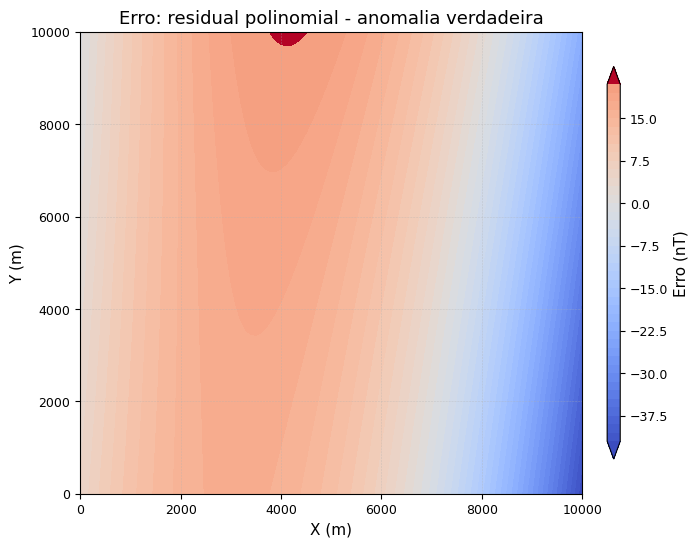

In [37]:
# ============================================================
# PLOT - ERRO DO RESIDUAL ESTIMADO
# ============================================================

fig_err_poly2, ax_err_poly2, cf_err_poly2 = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=erro_poly2,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Erro (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Erro: residual polinomial - anomalia verdadeira"
)

plt.show()

In [38]:
# ============================================================
# ETAPA 25 - TESTE COM DIFERENTES GRAUS POLINOMIAIS
# ============================================================

degrees_test = [1, 2, 3, 4]

regional_by_degree = {}
residual_by_degree = {}
metrics_by_degree = {}

for deg in degrees_test:
    
    regional_deg, coef_deg = fit_polynomial_regional_2d(
        x=x_mag,
        y=y_mag,
        data=tfa_observed,
        degree=deg
    )
    
    residual_deg = tfa_observed - regional_deg
    error_deg = residual_deg - tfa_prisms
    
    rmse_deg = np.sqrt(np.mean(error_deg**2))
    mae_deg = np.mean(np.abs(error_deg))
    corr_deg = np.corrcoef(residual_deg.ravel(), tfa_prisms.ravel())[0, 1]
    
    regional_by_degree[deg] = regional_deg
    residual_by_degree[deg] = residual_deg
    
    metrics_by_degree[deg] = {
        "rmse": rmse_deg,
        "mae": mae_deg,
        "correlation": corr_deg,
        "coefficients": coef_deg
    }
    
    print(f"Grau {deg}")
    print("RMSE:", rmse_deg)
    print("MAE:", mae_deg)
    print("Correlação:", corr_deg)
    print("-"*50)

Grau 1
RMSE: 12.54424867905721
MAE: 9.707933428165763
Correlação: 0.9573242859530237
--------------------------------------------------
Grau 2
RMSE: 15.38661942977763
MAE: 13.56729560230802
Correlação: 0.92933186297975
--------------------------------------------------
Grau 3
RMSE: 18.246333032434578
MAE: 15.681716199771808
Correlação: 0.8945919828450658
--------------------------------------------------
Grau 4
RMSE: 19.155477813931395
MAE: 15.763509667922662
Correlação: 0.8819827202799349
--------------------------------------------------


In [39]:
# ============================================================
# ETAPA 26 - ESCOLHER MELHOR GRAU POLINOMIAL
# ============================================================

best_degree = min(
    metrics_by_degree,
    key=lambda deg: metrics_by_degree[deg]["rmse"]
)

print("Melhor grau polinomial:", best_degree)
print("RMSE:", metrics_by_degree[best_degree]["rmse"])
print("MAE:", metrics_by_degree[best_degree]["mae"])
print("Correlação:", metrics_by_degree[best_degree]["correlation"])

tfa_residual_best_poly = residual_by_degree[best_degree]

Melhor grau polinomial: 1
RMSE: 12.54424867905721
MAE: 9.707933428165763
Correlação: 0.9573242859530237


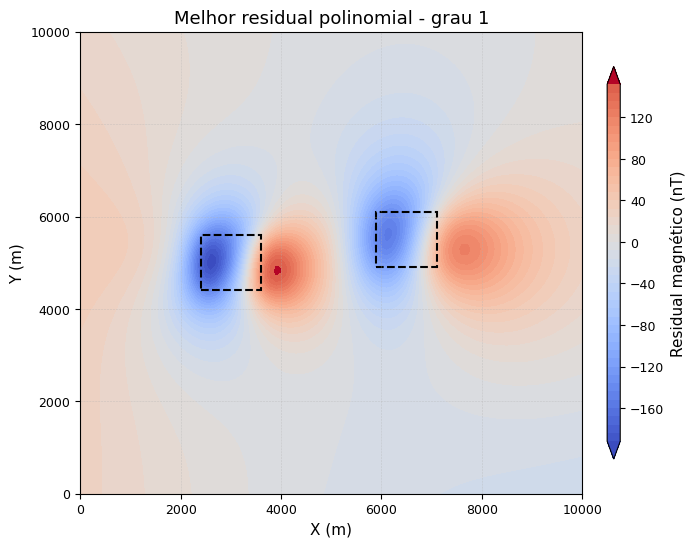

In [40]:
# ============================================================
# ETAPA 27 - PLOT DO MELHOR RESIDUAL POLINOMIAL
# ============================================================

fig_best_res, ax_best_res, cf_best_res = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual magnético (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title=f"Melhor residual polinomial - grau {best_degree}"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_best_res,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [41]:
# ============================================================
# ETAPA 19A - IMPORTAR O MÓDULO REGRES
# ============================================================

from gravmag_codes import regres

print("Módulo regres importado com sucesso!")
print("Arquivo usado:", regres.__file__)

Módulo regres importado com sucesso!
Arquivo usado: C:\Users\Usuario\Python_Notebooks\python-modeling\gravmag_codes\regres.py


In [42]:
tfa_observed = regional_mag + tfa_prisms

In [43]:
# ============================================================
# ETAPA 19B - ESTIMAR REGIONAL POR AJUSTE POLINOMIAL 2D
# ============================================================

result_poly2 = regres.my_remove_polynomial_regional_2d(
    x=x_mag,
    y=y_mag,
    data=tfa_observed,
    degree=2,
    full=True,
    normalize=True,
    normalize_mode="range",
    regulator=0.0,
    regularization="damping",
    flatten=False
)

regional_poly2 = result_poly2["regional"]
tfa_residual_poly2 = result_poly2["residual"]
coef_poly2 = result_poly2["coefficients"]

print("Regional polinomial estimado com sucesso!")
print("Grau:", result_poly2["degree"])
print("Solver:", result_poly2["solver"])
print("Coeficientes:", coef_poly2)
print("Regional mínimo/máximo:", np.min(regional_poly2), np.max(regional_poly2))
print("Residual mínimo/máximo:", np.min(tfa_residual_poly2), np.max(tfa_residual_poly2))

Regional polinomial estimado com sucesso!
Grau: 2
Solver: least_squares
Coeficientes: [133.78705394 -67.75156706 114.87614532 -20.66737667  13.76553614
 157.19628853]
Regional mínimo/máximo: 71.16800550265557 255.79175406170287
Residual mínimo/máximo: -195.44395175281096 163.39202836412778


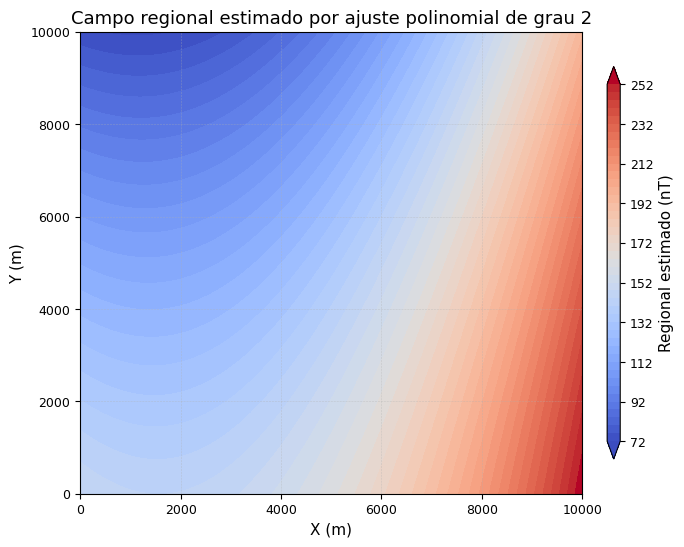

In [44]:
# ============================================================
# ETAPA 19C - PLOT DO REGIONAL ESTIMADO
# ============================================================

fig_reg_poly2, ax_reg_poly2, cf_reg_poly2 = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=regional_poly2,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Regional estimado (nT)",
    colormap="coolwarm",
    levels=50,
    title="Campo regional estimado por ajuste polinomial de grau 2"
)

plt.show()

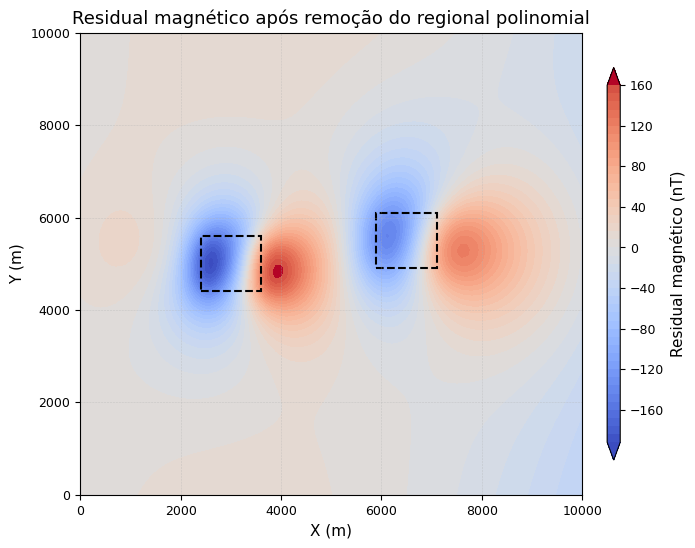

In [45]:
# ============================================================
# ETAPA 19D - PLOT DO RESIDUAL MAGNÉTICO
# ============================================================

fig_res_poly2, ax_res_poly2, cf_res_poly2 = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_poly2,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual magnético (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Residual magnético após remoção do regional polinomial"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_poly2,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [46]:
# ============================================================
# ETAPA 19E - MÉTRICAS DO RESIDUAL ESTIMADO
# ============================================================

metrics_poly2 = regres.my_regional_metrics(
    reference=tfa_prisms,
    estimated=tfa_residual_poly2
)

print("Métricas entre residual estimado e anomalia verdadeira")
print("RMSE:", metrics_poly2["rmse"], "nT")
print("MAE:", metrics_poly2["mae"], "nT")
print("Erro máximo absoluto:", metrics_poly2["max_abs_error"], "nT")
print("Correlação:", metrics_poly2["correlation"])

Métricas entre residual estimado e anomalia verdadeira
RMSE: 15.38661942977763 nT
MAE: 13.567295602308025 nT
Erro máximo absoluto: 43.29175406170286 nT
Correlação: 0.9293318629797501


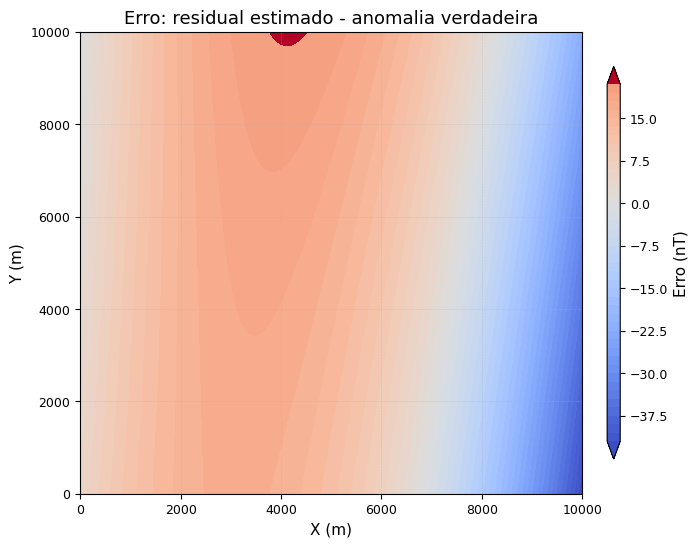

In [47]:
# ============================================================
# ETAPA 19F - PLOT DO ERRO DO RESIDUAL
# ============================================================

erro_poly2 = metrics_poly2["residual"]

fig_err_poly2, ax_err_poly2, cf_err_poly2 = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=erro_poly2,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Erro (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Erro: residual estimado - anomalia verdadeira"
)

plt.show()

In [48]:
# ============================================================
# ETAPA 20 - TESTAR DIFERENTES GRAUS POLINOMIAIS
# ============================================================

test_degrees = regres.my_test_polynomial_degrees_2d(
    x=x_mag,
    y=y_mag,
    data=tfa_observed,
    degrees=[1, 2, 3, 4],
    reference_residual=tfa_prisms,
    full=True,
    normalize=True,
    normalize_mode="range",
    regulator=0.0,
    regularization="damping"
)

best_degree = test_degrees["best_degree"]
best_result = test_degrees["best_result"]

print("Teste de graus polinomiais concluído!")
print("Melhor grau:", best_degree)

for degree, metrics in test_degrees["metrics_by_degree"].items():
    print("-"*50)
    print("Grau:", degree)
    print("RMSE:", metrics["rmse"])
    print("MAE:", metrics["mae"])
    print("Erro máximo absoluto:", metrics["max_abs_error"])
    print("Correlação:", metrics["correlation"])

Teste de graus polinomiais concluído!
Melhor grau: 1
--------------------------------------------------
Grau: 1
RMSE: 12.54424867905721
MAE: 9.707933428165763
Erro máximo absoluto: 31.421075424086784
Correlação: 0.9573242859530237
--------------------------------------------------
Grau: 2
RMSE: 15.38661942977763
MAE: 13.567295602308025
Erro máximo absoluto: 43.29175406170286
Correlação: 0.9293318629797501
--------------------------------------------------
Grau: 3
RMSE: 18.24633303243458
MAE: 15.681716199771808
Erro máximo absoluto: 56.46697232249625
Correlação: 0.8945919828450656
--------------------------------------------------
Grau: 4
RMSE: 19.155477813931356
MAE: 15.763509667922625
Erro máximo absoluto: 55.00201675195726
Correlação: 0.8819827202799354


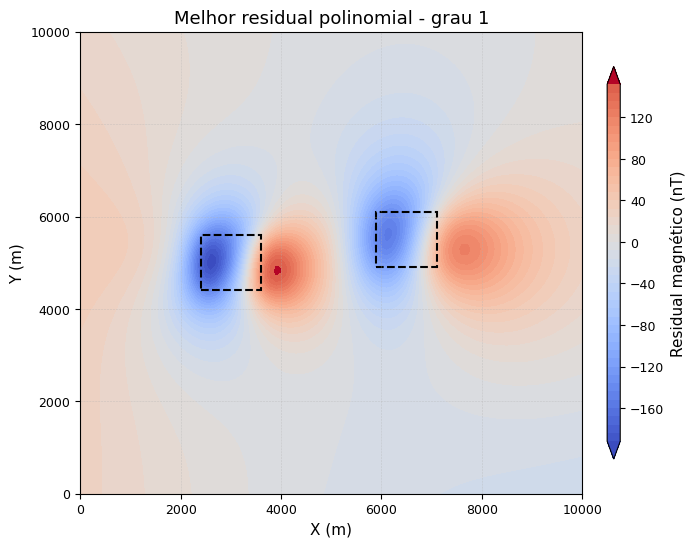

In [49]:
# ============================================================
# ETAPA 21 - MELHOR RESIDUAL POLINOMIAL
# ============================================================

regional_best_poly = best_result["regional"]
tfa_residual_best_poly = best_result["residual"]

fig_best_res, ax_best_res, cf_best_res = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual magnético (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title=f"Melhor residual polinomial - grau {best_degree}"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_best_res,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [50]:
# ============================================================
# ETAPA 22 - AJUSTE POLINOMIAL COM REGULARIZAÇÃO
# ============================================================

result_poly_reg = regres.my_remove_polynomial_regional_2d(
    x=x_mag,
    y=y_mag,
    data=tfa_observed,
    degree=4,
    full=True,
    normalize=True,
    normalize_mode="range",
    regulator=1.0e-3,
    regularization="curvature",
    flatten=False
)

regional_poly_reg = result_poly_reg["regional"]
tfa_residual_poly_reg = result_poly_reg["residual"]

metrics_poly_reg = regres.my_regional_metrics(
    reference=tfa_prisms,
    estimated=tfa_residual_poly_reg
)

print("Ajuste polinomial regularizado concluído!")
print("Grau:", result_poly_reg["degree"])
print("Regularização:", result_poly_reg["regularization"])
print("Regulador:", result_poly_reg["regulator"])
print("RMSE:", metrics_poly_reg["rmse"])
print("MAE:", metrics_poly_reg["mae"])
print("Correlação:", metrics_poly_reg["correlation"])

Ajuste polinomial regularizado concluído!
Grau: 4
Regularização: curvature
Regulador: 0.001
RMSE: 14.147916218556919
MAE: 12.70120942805498
Correlação: 0.9423834785752224


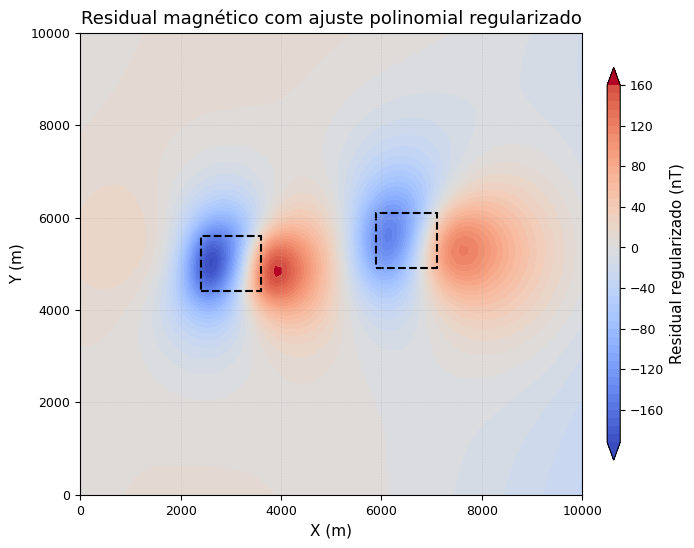

In [52]:
# ============================================================
# PLOT - RESIDUAL POLINOMIAL REGULARIZADO
# ============================================================

fig_res_reg, ax_res_reg, cf_res_reg = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_poly_reg,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual regularizado (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Residual magnético com ajuste polinomial regularizado"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_reg,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [53]:
# ============================================================
# ETAPA 23 - SALVAR RESULTADO REGIONAL-RESIDUAL
# ============================================================

import os

output_folder_regres = "dados_regional_residual"
os.makedirs(output_folder_regres, exist_ok=True)

regres.my_save_regional_result(
    filename=os.path.join(output_folder_regres, "regional_residual_magnetico.txt"),
    x=x_mag,
    y=y_mag,
    observed=tfa_observed,
    regional=regional_best_poly,
    residual=tfa_residual_best_poly
)

print("Resultado regional-residual salvo com sucesso!")
print("Arquivo:", os.path.join(output_folder_regres, "regional_residual_magnetico.txt"))

Resultado regional-residual salvo com sucesso!
Arquivo: dados_regional_residual\regional_residual_magnetico.txt


In [54]:
# ============================================================
# ETAPA 24 - DERIVADAS HORIZONTAIS DO RESIDUAL MAGNÉTICO
# ============================================================

res_dx = derivative.my_xderiv(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

res_dy = derivative.my_yderiv(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivadas horizontais do residual calculadas com sucesso!")
print("dR/dx mínimo/máximo:", np.min(res_dx), np.max(res_dx))
print("dR/dy mínimo/máximo:", np.min(res_dy), np.max(res_dy))

Derivadas horizontais do residual calculadas com sucesso!
dR/dx mínimo/máximo: -0.29961889356611004 0.4265067037495531
dR/dy mínimo/máximo: -0.17634938519705803 0.1556608753613748


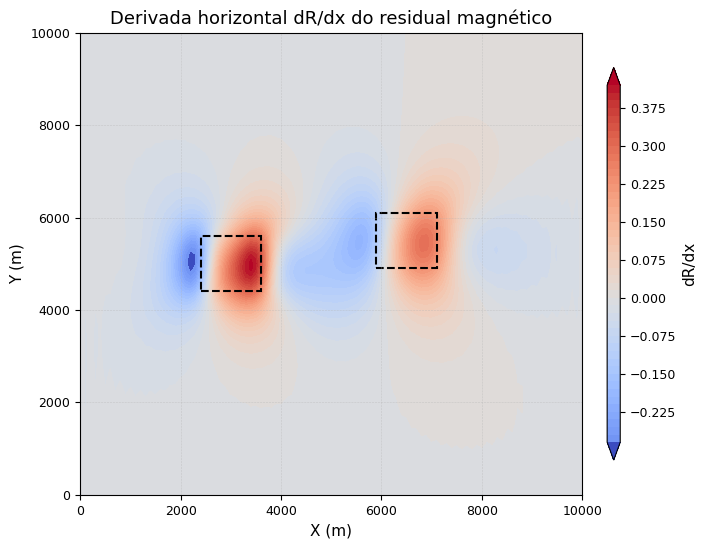

In [55]:
# ============================================================
# PLOT - DERIVADA HORIZONTAL dR/dx
# ============================================================

fig_res_dx, ax_res_dx, cf_res_dx = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=res_dx,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dR/dx",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada horizontal dR/dx do residual magnético"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_dx,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

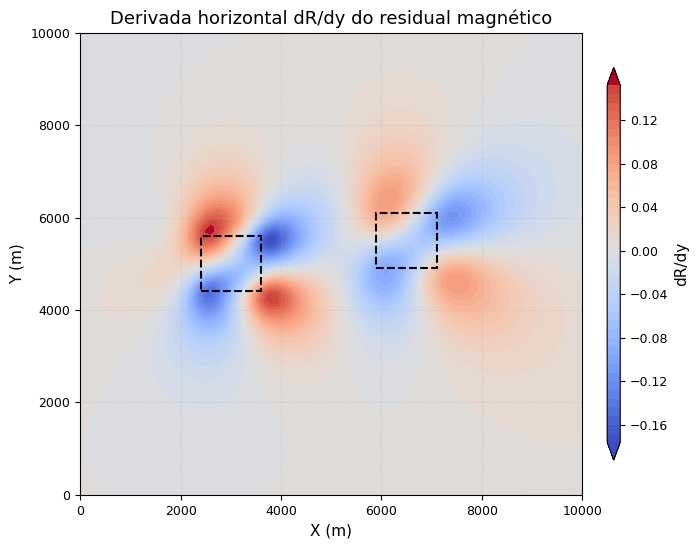

In [56]:
# ============================================================
# PLOT - DERIVADA HORIZONTAL dR/dy
# ============================================================

fig_res_dy, ax_res_dy, cf_res_dy = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=res_dy,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dR/dy",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada horizontal dR/dy do residual magnético"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_dy,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [57]:
# ============================================================
# ETAPA 25 - DERIVADA VERTICAL DO RESIDUAL MAGNÉTICO
# ============================================================

res_dz = derivative.my_zderiv(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivada vertical do residual calculada com sucesso!")
print("dR/dz mínimo/máximo:", np.min(res_dz), np.max(res_dz))

Derivada vertical do residual calculada com sucesso!
dR/dz mínimo/máximo: -0.4786468217159474 0.4353850683947311


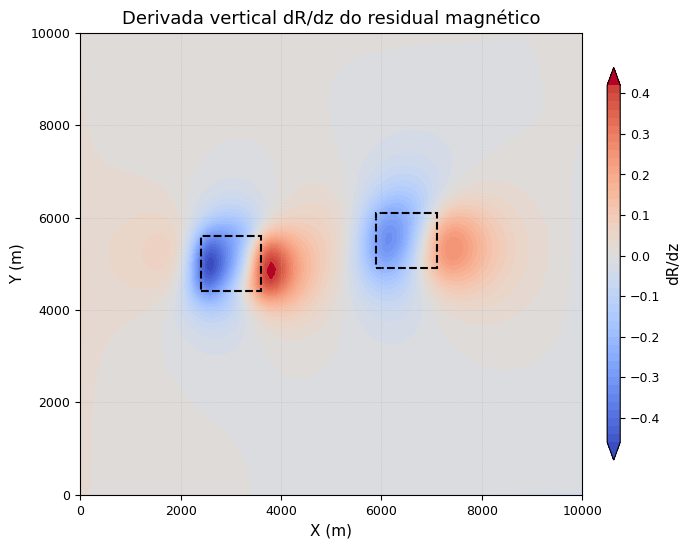

In [58]:
# ============================================================
# PLOT - DERIVADA VERTICAL dR/dz
# ============================================================

fig_res_dz, ax_res_dz, cf_res_dz = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=res_dz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dR/dz",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada vertical dR/dz do residual magnético"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_dz,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [59]:
# ============================================================
# ETAPA 26 - HGM DO RESIDUAL MAGNÉTICO
# ============================================================

hgm_res = derivative.my_hgrad(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("HGM do residual calculado com sucesso!")
print("HGM mínimo/máximo:", np.min(hgm_res), np.max(hgm_res))

HGM do residual calculado com sucesso!
HGM mínimo/máximo: 2.5076195839990778e-05 0.43292178909925777


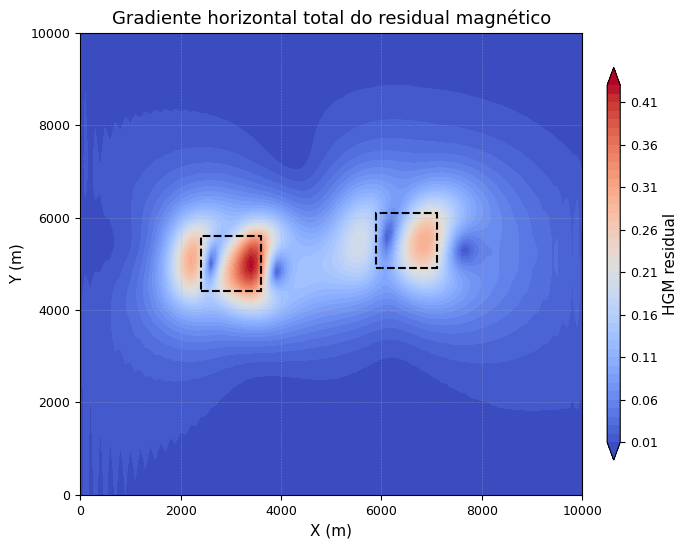

In [61]:
# ============================================================
# PLOT - HGM DO RESIDUAL
# ============================================================

fig_hgm_res, ax_hgm_res, cf_hgm_res = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=hgm_res,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="HGM residual",
    colormap="coolwarm",
    levels=50,
    title="Gradiente horizontal total do residual magnético"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_hgm_res,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [62]:
# ============================================================
# ETAPA 27 - SINAL ANALÍTICO DO RESIDUAL MAGNÉTICO
# ============================================================

asa_res = derivative.my_totalgrad(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Sinal analítico do residual calculado com sucesso!")
print("ASA mínimo/máximo:", np.min(asa_res), np.max(asa_res))

Sinal analítico do residual calculado com sucesso!
ASA mínimo/máximo: 0.0020042856140625844 0.4787440661422149


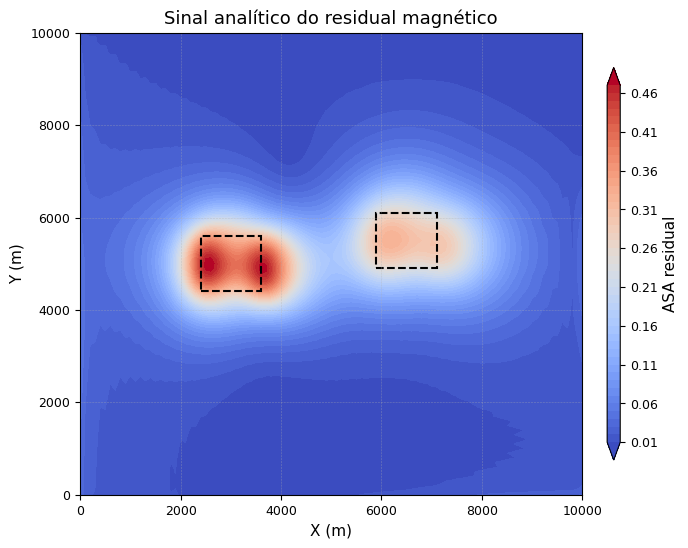

In [65]:
# ============================================================
# PLOT - SINAL ANALÍTICO DO RESIDUAL
# ============================================================

fig_asa_res, ax_asa_res, cf_asa_res = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=asa_res,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="ASA residual",
    colormap="coolwarm",
    levels=50,
    title="Sinal analítico do residual magnético"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_asa_res,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [66]:
# ============================================================
# ETAPA 28 - TILT ANGLE DO RESIDUAL MAGNÉTICO
# ============================================================

tilt_res = filtering.my_tilt(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_best_poly,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    degrees=True,
    flatten=False
)

print("Tilt angle do residual calculado com sucesso!")
print("Tilt mínimo/máximo:", np.min(tilt_res), np.max(tilt_res), "graus")

Tilt angle do residual calculado com sucesso!
Tilt mínimo/máximo: -89.859579231011 89.94817259767045 graus


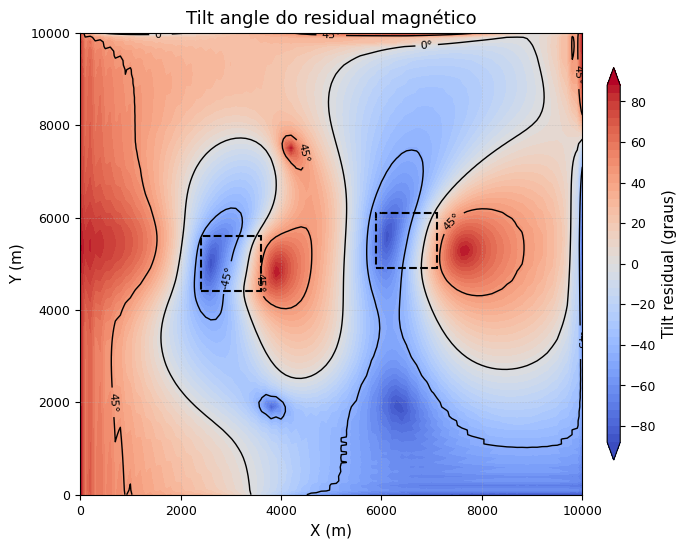

In [67]:
# ============================================================
# PLOT - TILT ANGLE DO RESIDUAL
# ============================================================

fig_tilt_res, ax_tilt_res, cf_tilt_res = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tilt_res,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Tilt residual (graus)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Tilt angle do residual magnético"
)

plotting.my_contour(
    x=x_mag,
    y=y_mag,
    data=tilt_res,
    ax=ax_tilt_res,
    levels=[-45, 0, 45],
    colors="black",
    linewidths=1.0,
    linestyles="-",
    clabel=True,
    clabel_fmt="%.0f°"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tilt_res,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [68]:
# ============================================================
# ETAPA 29 - SELECIONAR NÓS PARA INTERPOLAÇÃO DE LAGRANGE
# ============================================================

# Número de nós em cada direção
nx_nodes = 4
ny_nodes = 4

# Vetores de nós em x e y
x_nodes = np.linspace(np.min(x_mag), np.max(x_mag), nx_nodes)
y_nodes = np.linspace(np.min(y_mag), np.max(y_mag), ny_nodes)

# Função auxiliar simples para pegar o valor mais próximo no grid observado
def nearest_grid_value(xgrid, ygrid, data, x0, y0):
    dist2 = (xgrid - x0)**2 + (ygrid - y0)**2
    idx = np.unravel_index(np.argmin(dist2), data.shape)
    return data[idx]

# Matriz dos valores observados nos nós
values_nodes = np.zeros((ny_nodes, nx_nodes))

for iy, ynode in enumerate(y_nodes):
    for ix, xnode in enumerate(x_nodes):
        values_nodes[iy, ix] = nearest_grid_value(
            xgrid=x_mag,
            ygrid=y_mag,
            data=tfa_observed,
            x0=xnode,
            y0=ynode
        )

print("Nós de Lagrange selecionados com sucesso!")
print("x_nodes:", x_nodes)
print("y_nodes:", y_nodes)
print("Shape dos valores nos nós:", values_nodes.shape)

Nós de Lagrange selecionados com sucesso!
x_nodes: [    0.          3333.33333333  6666.66666667 10000.        ]
y_nodes: [    0.          3333.33333333  6666.66666667 10000.        ]
Shape dos valores nos nós: (4, 4)


In [69]:
# ============================================================
# ETAPA 30 - REGIONAL POR INTERPOLAÇÃO DE LAGRANGE 2D
# ============================================================

regional_lagrange = regres.my_lagrange_interpolate_2d_tensor(
    x_nodes=x_nodes,
    y_nodes=y_nodes,
    values=values_nodes,
    x_eval=x_mag,
    y_eval=y_mag
)

tfa_residual_lagrange = tfa_observed - regional_lagrange

print("Regional por Lagrange calculado com sucesso!")
print("Regional Lagrange mínimo/máximo:", np.min(regional_lagrange), np.max(regional_lagrange))
print("Residual Lagrange mínimo/máximo:", np.min(tfa_residual_lagrange), np.max(tfa_residual_lagrange))

Regional por Lagrange calculado com sucesso!
Regional Lagrange mínimo/máximo: 67.38257958338818 222.56437155749057
Residual Lagrange mínimo/máximo: -185.26029215789822 183.33162792112768


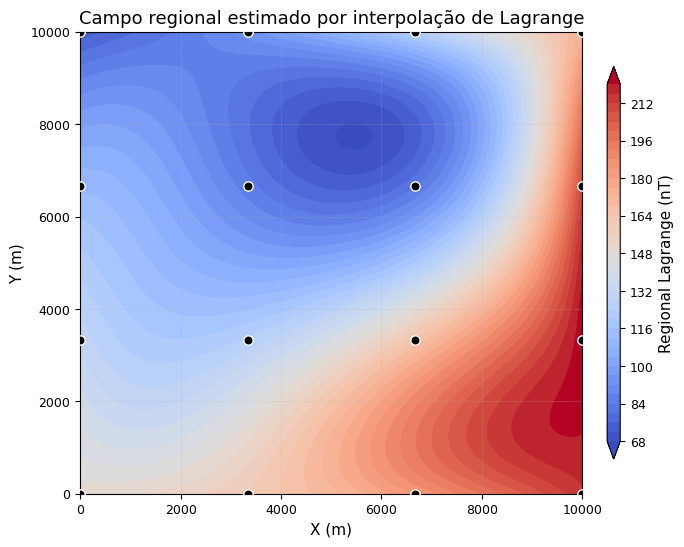

In [70]:
# ============================================================
# ETAPA 31 - PLOT DO REGIONAL POR LAGRANGE
# ============================================================

fig_reg_lag, ax_reg_lag, cf_reg_lag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=regional_lagrange,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Regional Lagrange (nT)",
    colormap="coolwarm",
    levels=50,
    title="Campo regional estimado por interpolação de Lagrange"
)

# Marca os nós usados na interpolação
for ynode in y_nodes:
    for xnode in x_nodes:
        ax_reg_lag.scatter(
            xnode,
            ynode,
            s=45,
            color="black",
            marker="o",
            edgecolor="white",
            zorder=5
        )

plt.show()

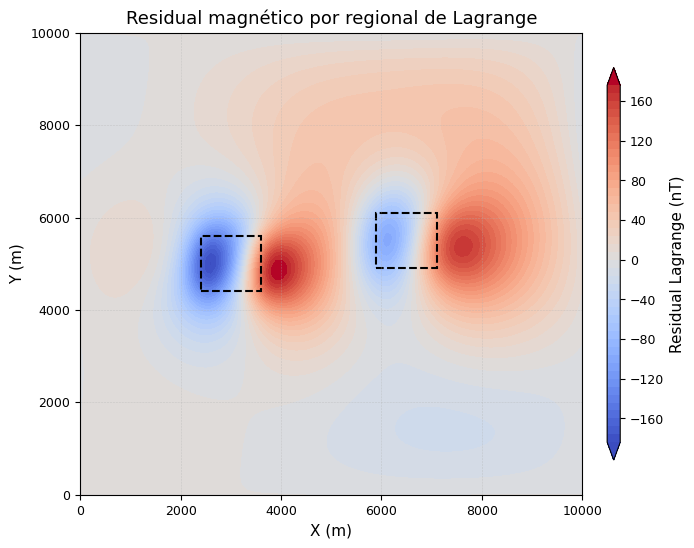

In [71]:
# ============================================================
# ETAPA 32 - PLOT DO RESIDUAL POR LAGRANGE
# ============================================================

fig_res_lag, ax_res_lag, cf_res_lag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_lagrange,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Residual Lagrange (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Residual magnético por regional de Lagrange"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res_lag,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [72]:
# ============================================================
# ETAPA 33 - MÉTRICAS DO RESIDUAL POR LAGRANGE
# ============================================================

metrics_lagrange = regres.my_regional_metrics(
    reference=tfa_prisms,
    estimated=tfa_residual_lagrange
)

print("Métricas entre residual Lagrange e anomalia verdadeira")
print("RMSE:", metrics_lagrange["rmse"], "nT")
print("MAE:", metrics_lagrange["mae"], "nT")
print("Erro máximo absoluto:", metrics_lagrange["max_abs_error"], "nT")
print("Correlação:", metrics_lagrange["correlation"])

Métricas entre residual Lagrange e anomalia verdadeira
RMSE: 30.394267685741795 nT
MAE: 22.959616334896165 nT
Erro máximo absoluto: 75.22816220114038 nT
Correlação: 0.8163089323899252


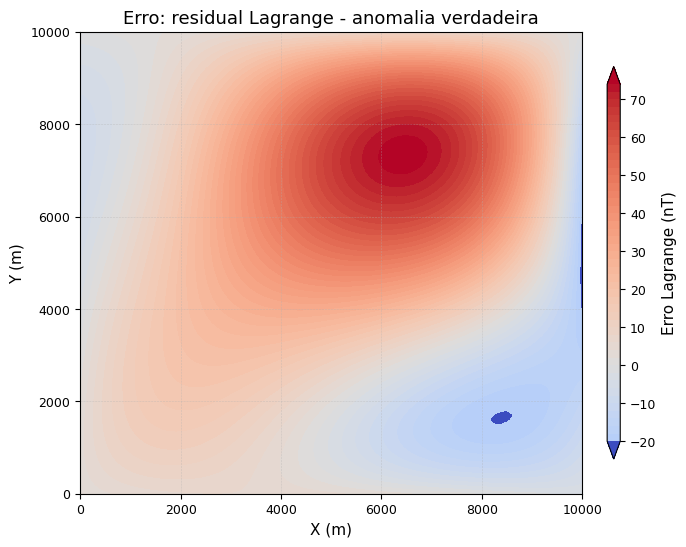

In [73]:
# ============================================================
# PLOT - ERRO DO RESIDUAL POR LAGRANGE
# ============================================================

erro_lagrange = metrics_lagrange["residual"]

fig_err_lag, ax_err_lag, cf_err_lag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=erro_lagrange,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Erro Lagrange (nT)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Erro: residual Lagrange - anomalia verdadeira"
)

plt.show()

In [74]:
# ============================================================
# ETAPA 34 - COMPARAÇÃO POLINOMIAL x LAGRANGE
# ============================================================

print("Comparação dos métodos regional-residual")
print("-"*60)
print("Polinomial")
print("Melhor grau:", best_degree)

metrics_best_poly = regres.my_regional_metrics(
    reference=tfa_prisms,
    estimated=tfa_residual_best_poly
)

print("RMSE:", metrics_best_poly["rmse"])
print("MAE:", metrics_best_poly["mae"])
print("Correlação:", metrics_best_poly["correlation"])

print("-"*60)
print("Lagrange")
print("Número de nós:", nx_nodes, "x", ny_nodes)
print("RMSE:", metrics_lagrange["rmse"])
print("MAE:", metrics_lagrange["mae"])
print("Correlação:", metrics_lagrange["correlation"])

Comparação dos métodos regional-residual
------------------------------------------------------------
Polinomial
Melhor grau: 1
RMSE: 12.54424867905721
MAE: 9.707933428165763
Correlação: 0.9573242859530237
------------------------------------------------------------
Lagrange
Número de nós: 4 x 4
RMSE: 30.394267685741795
MAE: 22.959616334896165
Correlação: 0.8163089323899252


In [75]:
# ============================================================
# ETAPA 35 - TILT ANGLE DO RESIDUAL POR LAGRANGE
# ============================================================

tilt_lagrange = filtering.my_tilt(
    x=x_mag,
    y=y_mag,
    data=tfa_residual_lagrange,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    degrees=True,
    flatten=False
)

print("Tilt do residual Lagrange calculado com sucesso!")
print("Tilt mínimo/máximo:", np.min(tilt_lagrange), np.max(tilt_lagrange), "graus")

Tilt do residual Lagrange calculado com sucesso!
Tilt mínimo/máximo: -89.96346889717329 89.75426171947116 graus


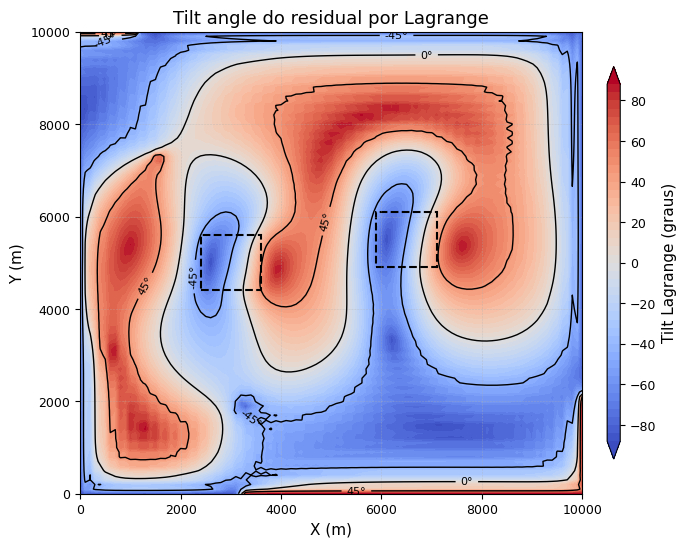

In [76]:
# ============================================================
# PLOT - TILT ANGLE DO RESIDUAL POR LAGRANGE
# ============================================================

fig_tilt_lag, ax_tilt_lag, cf_tilt_lag = plotting.my_contourf(
    x=x_mag,
    y=y_mag,
    data=tilt_lagrange,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Tilt Lagrange (graus)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Tilt angle do residual por Lagrange"
)

plotting.my_contour(
    x=x_mag,
    y=y_mag,
    data=tilt_lagrange,
    ax=ax_tilt_lag,
    levels=[-45, 0, 45],
    colors="black",
    linewidths=1.0,
    linestyles="-",
    clabel=True,
    clabel_fmt="%.0f°"
)

for p in prisms_mag:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tilt_lag,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [77]:
# ============================================================
# ETAPA 36 - SALVAR RESULTADOS REGIONAL-RESIDUAL
# ============================================================

output_folder_regres = "dados_regional_residual"
os.makedirs(output_folder_regres, exist_ok=True)

# Salva resultado polinomial
regres.my_save_regional_result(
    filename=os.path.join(output_folder_regres, "regional_residual_polinomial.txt"),
    x=x_mag,
    y=y_mag,
    observed=tfa_observed,
    regional=regional_best_poly,
    residual=tfa_residual_best_poly
)

# Salva resultado Lagrange
regres.my_save_regional_result(
    filename=os.path.join(output_folder_regres, "regional_residual_lagrange.txt"),
    x=x_mag,
    y=y_mag,
    observed=tfa_observed,
    regional=regional_lagrange,
    residual=tfa_residual_lagrange
)

print("Resultados regional-residual salvos com sucesso!")
print("Pasta:", output_folder_regres)

Resultados regional-residual salvos com sucesso!
Pasta: dados_regional_residual
